In [1]:
import os
import pandas as pd
import numpy as np

# ============================================================
# Configuration
# ============================================================
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion"
rain_filter_threshold = 10
shift_threshold       = 20000

# ============================================================
# Table S1 from Armon et al. 2020
# ============================================================
hpe_table = [
    (1,  "02-11-1991 09:00", "05-11-1991 09:00", "MC"),
    (2,  "22-02-1992 08:00", "27-02-1992 21:00", "MC"),
    (3,  "23-11-1992 09:00", "26-11-1992 07:00", "MC"),
    (4,  "12-12-1992 14:00", "18-12-1992 13:00", "MC"),
    (5,  "31-03-1993 09:00", "02-04-1993 02:00", "ARST"),
    (6,  "21-12-1993 12:00", "23-12-1993 15:00", "ARST"),
    (7,  "21-02-1994 19:00", "25-02-1994 00:00", "MC"),
    (8,  "01-11-1994 15:00", "07-11-1994 13:00", "ARST"),
    (9,  "14-11-1994 01:00", "18-11-1994 05:00", "MC"),
    (10, "15-12-1994 12:00", "20-12-1994 21:00", "MC"),
    (11, "28-12-1994 10:00", "31-12-1994 23:00", "MC"),
    (12, "04-02-1995 08:00", "09-02-1995 10:00", "MC"),
    (13, "01-11-1995 11:00", "03-11-1995 14:00", "MC"),
    (14, "07-11-1995 10:00", "10-11-1995 17:00", "MC"),
    (15, "06-03-1996 13:00", "08-03-1996 04:00", "MC"),
    (16, "11-12-1996 14:00", "14-12-1996 15:00", "ARST"),
    (17, "13-01-1997 11:00", "17-01-1997 07:00", "MC"),
    (18, "03-03-1997 06:00", "04-03-1997 16:00", "MC"),
    (19, "19-10-1997 11:00", "20-10-1997 10:00", "MC"),
    (20, "25-11-1997 10:00", "27-11-1997 09:00", "ARST"),
    (21, "04-04-1998 04:00", "04-04-1998 17:00", "MC"),
    (22, "28-12-1998 06:00", "31-12-1998 21:00", "MC"),
    (23, "13-12-1999 06:00", "15-12-1999 08:00", "MC"),
    (24, "18-01-2000 06:00", "24-01-2000 02:00", "MC"),
    (25, "25-01-2000 15:00", "28-01-2000 20:00", "MC"),
    (26, "12-02-2000 22:00", "16-02-2000 16:00", "MC"),
    (27, "29-11-2000 00:00", "01-12-2000 10:00", "MC"),
    (28, "19-12-2000 06:00", "21-12-2000 17:00", "MC"),
    (29, "30-04-2001 09:00", "02-05-2001 17:00", "MC"),
    (30, "09-12-2002 06:00", "12-12-2002 06:00", "MC"),
    (31, "02-01-2003 16:00", "04-01-2003 12:00", "MC"),
    (32, "27-01-2003 10:00", "30-01-2003 13:00", "MC"),
    (33, "03-02-2003 00:00", "05-02-2003 16:00", "MC"),
    (34, "17-02-2003 19:00", "22-02-2003 23:00", "MC"),
    (35, "24-02-2003 01:00", "28-02-2003 02:00", "MC"),
    (36, "01-12-2003 14:00", "05-12-2003 20:00", "ARST"),
    (37, "14-12-2003 16:00", "15-12-2003 10:00", "MC"),
    (38, "15-12-2005 15:00", "18-12-2005 09:00", "MC"),
    (39, "18-12-2007 14:00", "21-12-2007 08:00", "MC"),
    (40, "02-01-2008 03:00", "05-01-2008 19:00", "MC"),
    (41, "17-01-2010 16:00", "22-01-2010 06:00", "MC"),
]

df_hpe = pd.DataFrame(hpe_table, columns=["HPE #", "Start Time", "End Time", "Synoptic Classification"])

# ============================================================
# Load pickle
# ============================================================
pickle_file_path = os.path.join(sim_dir, 'urbanization_1_0.pkl')
df = pd.read_pickle(pickle_file_path)
df_d0 = df[df[('d', '', '')] == 0].copy()

# ============================================================
# Get historical and future total_rain per event (d==0 only)
# ============================================================
rain_per_event = (
    pd.DataFrame({
        'HPE #':        df_d0[('event_num',  '',            '')].values.astype(int),
        'Hist. [mm]':   df_d0[('historical', 'full_basin', 'total_rain')].values,
        'Fut. [mm]':    df_d0[('future',     'full_basin', 'total_rain')].values,
    })
    .groupby('HPE #')[['Hist. [mm]', 'Fut. [mm]']]
    .mean()
    .round(2)
    .reset_index()
)

# ============================================================
# SWMM filter (exact replica of filter_events_by_rainfall)
# event is excluded only if BOTH hist AND future are below threshold
# ============================================================
event_nums_to_filter_out = []

for event in df[('event_num', '', '')].unique():
    event_df = df[df[('event_num', '', '')] == event]

    rain_condition = (
        (event_df[('historical', 'full_basin', 'total_rain')] < rain_filter_threshold).all() and
        (event_df[('future',     'full_basin', 'total_rain')] < rain_filter_threshold).all()
    )
    hist_q = event_df[('historical', 'basin discharge', 'max_discharge')].values
    fut_q  = event_df[('future',     'basin discharge', 'max_discharge')].values
    shift_condition = abs(fut_q - hist_q) > shift_threshold

    if rain_condition or shift_condition.any():
        event_nums_to_filter_out.append(int(event))

# ============================================================
# Build final table
# ============================================================
df_final = df_hpe.merge(rain_per_event, on='HPE #', how='left')
df_final['Used in SWMM'] = df_final['HPE #'].apply(
    lambda x: '✓' if x not in event_nums_to_filter_out else ''
)

# ============================================================
# Print
# ============================================================
print(df_final.to_string(index=False))
print(f"\nTotal events used in SWMM: {(df_final['Used in SWMM'] == '✓').sum()} / {len(df_final)}")

# ============================================================
# Export to Excel
# ============================================================
output_path = os.path.join(sim_dir, 'HPE_summary_table.xlsx')
df_final.to_excel(output_path, index=False)
print(f"\nSaved to: {output_path}")

 HPE #       Start Time         End Time Synoptic Classification  Hist. [mm]  Fut. [mm] Used in SWMM
     1 02-11-1991 09:00 05-11-1991 09:00                      MC       26.64      26.15            ✓
     2 22-02-1992 08:00 27-02-1992 21:00                      MC      182.58     157.39            ✓
     3 23-11-1992 09:00 26-11-1992 07:00                      MC       55.95      38.00            ✓
     4 12-12-1992 14:00 18-12-1992 13:00                      MC      217.48     269.61            ✓
     5 31-03-1993 09:00 02-04-1993 02:00                    ARST        0.01       0.05             
     6 21-12-1993 12:00 23-12-1993 15:00                    ARST        0.01       0.02             
     7 21-02-1994 19:00 25-02-1994 00:00                      MC       10.50      29.71            ✓
     8 01-11-1994 15:00 07-11-1994 13:00                    ARST       59.34      13.87            ✓
     9 14-11-1994 01:00 18-11-1994 05:00                      MC       78.44      50.63    

C:\Users\raznu\AppData\Local\Temp\ipykernel_28396\2997511100.py:24: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  lat = np.array(f['lat'])
C:\Users\raznu\AppData\Local\Temp\ipykernel_28396\2997511100.py:25: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  lon = np.array(f['lon'])


✓ WRF domain shapefile saved
Radar coords:
  lon=34.8147  lat=32.0081
Station coords:
  lon=34.8759  lat=32.2008


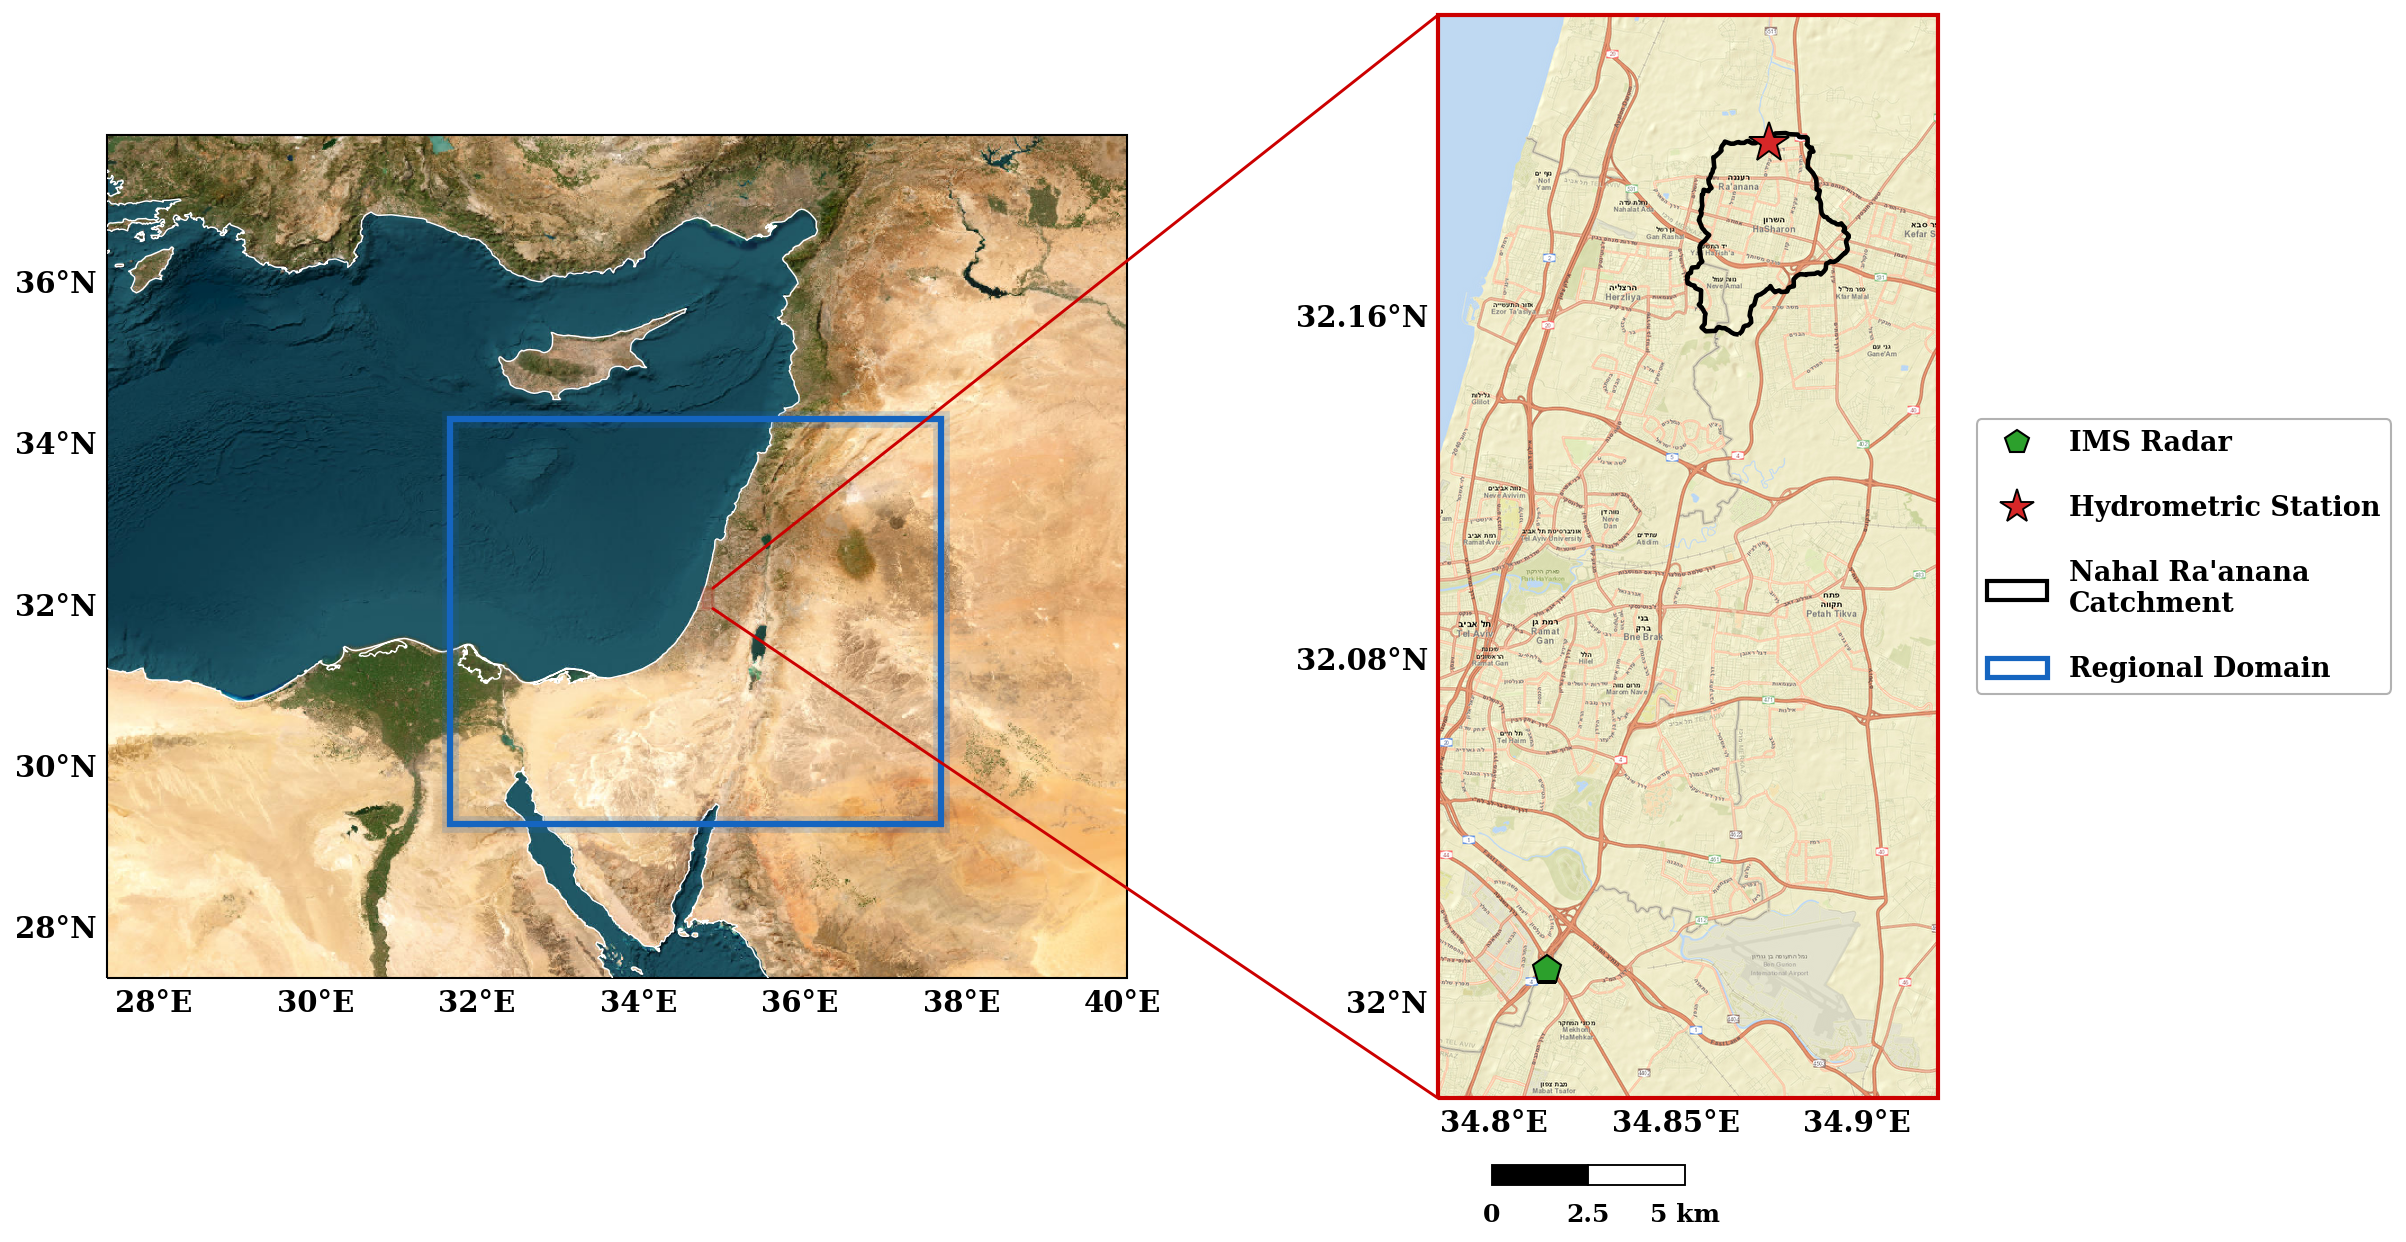

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.patches import ConnectionPatch
from shapely.geometry import box
import contextily as ctx

plt.rcParams['figure.dpi'] = 150

# ════════════════════════════════════════════════════════════════════════════
# 1.  Load data
# ════════════════════════════════════════════════════════════════════════════

mat_path = r'\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'
with h5py.File(mat_path, 'r') as f:
    lat = np.array(f['lat'])
    lon = np.array(f['lon'])

wrf_lat_min, wrf_lat_max = lat.min(), lat.max()
wrf_lon_min, wrf_lon_max = lon.min(), lon.max()

# ── Export WRF domain as Shapefile ───────────────────────────────────────────
wrf_domain_gdf = gpd.GeoDataFrame(
    {"name": ["WRF Regional Domain"]},
    geometry=[box(wrf_lon_min, wrf_lat_min, wrf_lon_max, wrf_lat_max)],
    crs="EPSG:4326",
)
wrf_domain_gdf.to_file(
    r'D:\Development\RESEARCH\Raanana\gis\raanana watershead\WRF_domain.shp'
)
print("✓ WRF domain shapefile saved")

# ── Vector layers ─────────────────────────────────────────────────────────────
gdb_path  = r'D:\Development\RESEARCH\Raanana\gis\raanana watershead\Default.gdb'
catchment = gpd.read_file(
    r'D:\Development\RESEARCH\Raanana\gis\GIS\SERS_imperviousdata\Raanana_wsp.shp'
).to_crs("EPSG:4326").dissolve()
station   = gpd.read_file(gdb_path, layer='OutLET_cATCHMENT').to_crs("EPSG:4326")
radar     = gpd.read_file(gdb_path, layer='IMSRADAR').to_crs("EPSG:4326")

print("Radar coords:")
for _, r in radar.iterrows():
    print(f"  lon={r.geometry.x:.4f}  lat={r.geometry.y:.4f}")
print("Station coords:")
for _, r in station.iterrows():
    print(f"  lon={r.geometry.x:.4f}  lat={r.geometry.y:.4f}")

# ════════════════════════════════════════════════════════════════════════════
# 2.  Extents
# ════════════════════════════════════════════════════════════════════════════

# Right panel — around catchment, tight south, generous north
b         = catchment.total_bounds
pad_lon   = (b[2] - b[0]) * 0.55
pad_north = (b[3] - b[1]) * 0.55
pad_south = (b[3] - b[1]) * 0.25

right_extent = [
    b[0] - pad_lon,
    b[2] + pad_lon,
    b[1] - pad_south,
    b[3] + pad_north,
]

# Ensure radar & station are inside extent
all_lons = [r.geometry.x for _, r in radar.iterrows()] + \
           [r.geometry.x for _, r in station.iterrows()]
all_lats = [r.geometry.y for _, r in radar.iterrows()] + \
           [r.geometry.y for _, r in station.iterrows()]
margin = 0.03
right_extent[0] = min(right_extent[0], min(all_lons) - margin)
right_extent[1] = max(right_extent[1], max(all_lons) + margin)
right_extent[2] = min(right_extent[2], min(all_lats) - margin)
right_extent[3] = max(right_extent[3], max(all_lats) + margin)

zx0, zx1 = right_extent[0], right_extent[1]
zy0, zy1 = right_extent[2], right_extent[3]

# Left panel — zoomed out more north & west
m_south = (wrf_lat_max - wrf_lat_min) * 0.38
m_north = (wrf_lat_max - wrf_lat_min) * 0.70
m_east  = (wrf_lon_max - wrf_lon_min) * 0.38
m_west  = (wrf_lon_max - wrf_lon_min) * 0.70

left_extent = [
    wrf_lon_min - m_west,  wrf_lon_max + m_east,
    wrf_lat_min - m_south, wrf_lat_max + m_north,
]

# ════════════════════════════════════════════════════════════════════════════
# 3.  Tile source — satellite (left panel only)
# ════════════════════════════════════════════════════════════════════════════

class ESRIImagery(cimgt.GoogleTiles):
    def _image_url(self, tile):
        x, y, z = tile
        return ("https://server.arcgisonline.com/ArcGIS/rest/services/"
                f"World_Imagery/MapServer/tile/{z}/{y}/{x}")

proj            = ccrs.PlateCarree()
satellite_tiles = ESRIImagery()

DOMAIN_COLOR = "#1565C0"
ZOOM_COLOR   = "#CC0000"
FONT         = "serif"
LABEL_SIZE   = 14
LEGEND_SIZE  = 13
SCALEBAR_SIZE= 12

# ════════════════════════════════════════════════════════════════════════════
# 4.  Figure & axes
# ════════════════════════════════════════════════════════════════════════════

fig  = plt.figure(figsize=(17, 8.5), facecolor="white")
ax_l = fig.add_axes([0.02, 0.10, 0.40, 0.85], projection=proj)
ax_r = fig.add_axes([0.44, 0.10, 0.40, 0.85], projection=proj)

# ════════════════════════════════════════════════════════════════════════════
# 5.  LEFT PANEL — satellite + WRF domain + zoom box
# ════════════════════════════════════════════════════════════════════════════

ax_l.set_extent(left_extent, crs=proj)
ax_l.add_image(satellite_tiles, 7)
ax_l.add_feature(cfeature.COASTLINE.with_scale("10m"),
                 linewidth=0.7, edgecolor="white", zorder=5)

# WRF domain — blue thick
for lw, alpha in [(8.0, 0.18), (3.0, 1.0)]:
    ax_l.add_patch(mpatches.FancyBboxPatch(
        (wrf_lon_min, wrf_lat_min),
        wrf_lon_max - wrf_lon_min, wrf_lat_max - wrf_lat_min,
        boxstyle="square,pad=0",
        linewidth=lw, edgecolor=DOMAIN_COLOR,
        facecolor="none", alpha=alpha,
        transform=proj, zorder=10,
    ))

# Zoom box — red, matches right panel border
ax_l.add_patch(mpatches.FancyBboxPatch(
    (zx0, zy0), zx1 - zx0, zy1 - zy0,
    boxstyle="square,pad=0",
    linewidth=1.8, edgecolor=ZOOM_COLOR,
    facecolor=ZOOM_COLOR, alpha=0.12,
    transform=proj, zorder=11,
))

gl_l = ax_l.gridlines(draw_labels=True, linewidth=0, color="none")
gl_l.top_labels   = False
gl_l.right_labels = False
gl_l.xformatter   = LONGITUDE_FORMATTER
gl_l.yformatter   = LATITUDE_FORMATTER
gl_l.xlabel_style = {"size": LABEL_SIZE, "fontfamily": FONT,
                     "color": "black", "weight": "bold"}
gl_l.ylabel_style = {"size": LABEL_SIZE, "fontfamily": FONT,
                     "color": "black", "weight": "bold"}
gl_l.xlocator = mticker.MultipleLocator(2)
gl_l.ylocator = mticker.MultipleLocator(2)

for spine in ax_l.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(1.0)

# ════════════════════════════════════════════════════════════════════════════
# 6.  Connecting lines
# ════════════════════════════════════════════════════════════════════════════

for xy_a, xy_b in [
    ((zx1, zy1), (0.0, 1.0)),
    ((zx1, zy0), (0.0, 0.0)),
]:
    fig.add_artist(ConnectionPatch(
        xyA=xy_a, coordsA=proj._as_mpl_transform(ax_l),
        xyB=xy_b, coordsB=ax_r.transAxes,
        color=ZOOM_COLOR, linewidth=1.4, zorder=30,
    ))

# ════════════════════════════════════════════════════════════════════════════
# 7.  RIGHT PANEL — contextily street map (zoom 13 = city names visible)
# ════════════════════════════════════════════════════════════════════════════

ax_r.set_extent(right_extent, crs=proj)
fig.canvas.draw()

ctx.add_basemap(
    ax_r,
    crs="EPSG:4326",
    source=ctx.providers.Esri.WorldStreetMap,
    zoom=13,
    interpolation="sinc",
    zorder=1,
)
ax_r.texts.clear()   # remove ESRI attribution

# Nahal Ra'anana catchment
catchment.plot(ax=ax_r, facecolor="none", edgecolor="black",
               linewidth=2.2, transform=proj, zorder=8)

# IMS Radar — green pentagon
for _, row in radar.iterrows():
    ax_r.plot(row.geometry.x, row.geometry.y,
              marker="p", markersize=14,
              markerfacecolor="#2ca02c",
              markeredgecolor="black", markeredgewidth=1.0,
              transform=proj, zorder=12)

# Hydrometric Station — red star, black outline
for _, row in station.iterrows():
    ax_r.plot(row.geometry.x, row.geometry.y,
              marker="*", markersize=20,
              markerfacecolor="#d62728",
              markeredgecolor="black", markeredgewidth=0.9,
              transform=proj, zorder=12)

gl_r = ax_r.gridlines(draw_labels=True, linewidth=0, color="none")
gl_r.top_labels   = False
gl_r.right_labels = False
gl_r.xformatter   = LONGITUDE_FORMATTER
gl_r.yformatter   = LATITUDE_FORMATTER
gl_r.xlabel_style = {"size": LABEL_SIZE, "fontfamily": FONT,
                     "color": "black", "weight": "bold"}
gl_r.ylabel_style = {"size": LABEL_SIZE, "fontfamily": FONT,
                     "color": "black", "weight": "bold"}
gl_r.xlocator = mticker.MultipleLocator(
    max(0.02, round((right_extent[1] - right_extent[0]) / 3, 2)))
gl_r.ylocator = mticker.MultipleLocator(
    max(0.02, round((right_extent[3] - right_extent[2]) / 3, 2)))

for spine in ax_r.spines.values():
    spine.set_edgecolor(ZOOM_COLOR); spine.set_linewidth(2.0)

# ════════════════════════════════════════════════════════════════════════════
# 8.  Scale bar — below right panel
# ════════════════════════════════════════════════════════════════════════════

bar_km   = 5
mid_lat  = (right_extent[2] + right_extent[3]) / 2
bar_deg  = bar_km / (111.0 * np.cos(np.radians(mid_lat)))
lon_span = right_extent[1] - right_extent[0]

pos_r    = ax_r.get_position()
bar_frac = bar_deg / lon_span
bar_y    = pos_r.y0 - 0.060
bar_xmid = pos_r.x0 + pos_r.width * 0.30
bar_x0   = bar_xmid - (bar_frac * pos_r.width) / 2
bar_x1   = bar_x0 + bar_frac * pos_r.width
half     = (bar_x1 - bar_x0) / 2
bar_h    = 0.016

for xs, xe, fc in [(bar_x0, bar_x0 + half, "black"),
                   (bar_x0 + half, bar_x1,  "white")]:
    fig.add_artist(plt.Rectangle(
        (xs, bar_y - bar_h / 2), xe - xs, bar_h,
        transform=fig.transFigure,
        facecolor=fc, edgecolor="black", linewidth=0.9,
        clip_on=False, zorder=20,
    ))

for xf, lbl in [(bar_x0, "0"), (bar_x0 + half, "2.5"), (bar_x1, "5 km")]:
    fig.text(xf, bar_y - bar_h / 2 - 0.014, lbl,
             ha="center", va="top",
             fontsize=SCALEBAR_SIZE, fontfamily=FONT,
             fontweight="bold", color="black")

# ════════════════════════════════════════════════════════════════════════════
# 9.  Legend — vertical, right of ax_r
# ════════════════════════════════════════════════════════════════════════════

legend_handles = [
    mlines.Line2D([], [], marker="p", color="w",
                  markerfacecolor="#2ca02c", markeredgecolor="black",
                  markeredgewidth=1.0, markersize=12,
                  label="IMS Radar"),
    mlines.Line2D([], [], marker="*", color="w",
                  markerfacecolor="#d62728", markeredgecolor="black",
                  markeredgewidth=0.9, markersize=17,
                  label="Hydrometric Station"),
    mpatches.Patch(facecolor="none", edgecolor="black",
                   linewidth=2.0,
                   label="Nahal Ra'anana\nCatchment"),
    mpatches.Patch(facecolor="none", edgecolor=DOMAIN_COLOR,
                   linewidth=2.5,
                   label="Regional Domain"),
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(pos_r.x1 + 0.010, pos_r.y0 + pos_r.height * 0.5),
    ncol=1,
    fontsize=LEGEND_SIZE,
    frameon=True,
    framealpha=0.9,
    edgecolor="#aaaaaa",
    prop={"family": FONT, "weight": "bold", "size": LEGEND_SIZE},
    labelspacing=1.4,
    handlelength=2.2,
    handletextpad=0.8,
)

plt.show()